<a href="https://colab.research.google.com/github/niloofarmaani/Are-Binns-just-GNNs-/blob/main/BINN_vs_GNN_TCGA_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip -q install wandb
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 1


wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: After creating your account, create a new API key and store it securely.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: niloofar-maani2 (niloofar-maani2-dfki) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# BINN vs GNN baselines on TCGA (Tumor vs Normal)
This notebook trains and compares:
- **Official BINN package baseline** (masked FFNN)
- **Layered-GNN baselines** (shared-weight GCN-style d=1, gated d=1, vector shared d=16)
- **Dense MLP baseline** (no graph)

Metrics compared:
- ROC-AUC on a fixed validation split
- Training speed (seconds/epoch)
- Inference speed (seconds per 1000 samples)
- CPU memory usage (RSS MB) during training/inference

Assumes you already created the cached artifacts in Drive under `binn_gnn_tcga/outputs/`.

In [ ]:
# ==== 0) Setup ====
from pathlib import Path
import os, json, time
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

BASE_DIR = Path('/content/drive/MyDrive/binn_gnn_tcga')
OUT_DIR = BASE_DIR / 'outputs'

# Cached dataset
EXPR_PARQUET = OUT_DIR / 'expr_reactome_tcga_tumor_normal.parquet'
Y_CSV = OUT_DIR / 'y_tcga_tumor_normal.csv'

# Reactome downloads (for BINN baseline)
REACTOME_DIR = OUT_DIR / 'reactome_downloads'
REACTOME_DIR.mkdir(parents=True, exist_ok=True)
ENSEMBL2R = REACTOME_DIR / 'Ensembl2Reactome.txt'
RELFILE = REACTOME_DIR / 'ReactomePathwaysRelation.txt'

# Layered graph artifacts (for layered-GNN variants)
GRAPH_LAYER_DIR = OUT_DIR / 'graph_layered_binn'
EDGE_INDEX_BY_LAYER_PT = GRAPH_LAYER_DIR / 'edge_index_by_layer.pt'
EDGE_ID_BY_LAYER_PT = GRAPH_LAYER_DIR / 'edge_id_by_layer.pt'
DST_NODES_BY_LAYER_PT = GRAPH_LAYER_DIR / 'dst_nodes_by_layer.pt'
LAYER_INFO_JSON = GRAPH_LAYER_DIR / 'layer_info.json'
GENE_LAYERED_IDS_PT = GRAPH_LAYER_DIR / 'gene_layered_ids_in_expr_order.pt'

# Optional convenience file
ROOT_PATHWAY_IDX_PT = GRAPH_LAYER_DIR / 'root_pathway_idx.pt'

# Run config (edit as needed)
SEED = 42
EPOCHS = 5          # increase for better comparisons
BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-5
DROPOUT = 0.2
D_VECTOR = 16
VAL_FRAC = 0.2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(SEED)

# Sanity checks
required = [EXPR_PARQUET, Y_CSV, EDGE_INDEX_BY_LAYER_PT, EDGE_ID_BY_LAYER_PT, DST_NODES_BY_LAYER_PT, LAYER_INFO_JSON, GENE_LAYERED_IDS_PT]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError('Missing required files:\n' + '\n'.join(missing))

# Ensure roots tensor exists
if ROOT_PATHWAY_IDX_PT.exists():
    root_pathway_idx = torch.load(ROOT_PATHWAY_IDX_PT).long()
else:
    with open(LAYER_INFO_JSON, 'r') as f:
        layer_info = json.load(f)
    root_pathway_idx = torch.tensor(layer_info['root_pathways_layered_ids'], dtype=torch.long)
    torch.save(root_pathway_idx, ROOT_PATHWAY_IDX_PT)
print('n_roots:', root_pathway_idx.numel())


device: cpu
n_roots: 29


## 1) Load cached dataset and make a fixed train/val split
We use the same split for all models to ensure fair metric comparisons.

In [ ]:
expr = pd.read_parquet(EXPR_PARQUET)   # genes x samples
y_df = pd.read_csv(Y_CSV, index_col=0)
# y_df has sample IDs as index, column 'y'
y_df = y_df.reset_index()
y_df.columns = ['sample','y']
y_df['sample'] = y_df['sample'].astype(str)
y_df['y'] = y_df['y'].astype(int)

# Align expression columns to y order
samples = y_df['sample'].tolist()
expr = expr.loc[:, samples]

# Convert to tensor X_gene: [S, G]
X_gene = torch.tensor(expr.to_numpy(dtype=np.float32).T)  # samples x genes
y = torch.tensor(y_df['y'].to_numpy(dtype=np.int64))

print('X_gene:', tuple(X_gene.shape), 'y:', tuple(y.shape), 'tumor_frac:', float(y.float().mean()))

idx = np.arange(len(samples))
train_idx, val_idx = train_test_split(idx, test_size=VAL_FRAC, random_state=SEED, stratify=y.numpy())
train_idx = torch.tensor(train_idx, dtype=torch.long)
val_idx = torch.tensor(val_idx, dtype=torch.long)

train_samples = [samples[i] for i in train_idx.tolist()]
val_samples = [samples[i] for i in val_idx.tolist()]

print('train:', len(train_samples), 'val:', len(val_samples))


X_gene: (9912, 11403) y: (9912,) tumor_frac: 0.926654577255249
train: 7929 val: 1983


## 2) Utilities: timing, memory, metrics

In [ ]:
!pip -q install psutil
import psutil
proc = psutil.Process(os.getpid())
def rss_mb():
    return proc.memory_info().rss / (1024**2)

class Timer:
    def __enter__(self):
        self.t0 = time.perf_counter(); return self
    def __exit__(self, *args):
        self.dt = time.perf_counter() - self.t0

def roc_auc(y_true, y_prob):
    return roc_auc_score(y_true, y_prob)

def inference_time_per_1k(fn, n, batch=256):
    # fn should accept a tensor batch and return probs
    # measure seconds per 1000 samples
    # warmup
    if n == 0:
        return float('nan')
    m = min(n, batch)
    _ = fn(torch.zeros((m, X_gene.shape[1]), dtype=torch.float32, device=device))
    # timed
    with Timer() as t:
        i = 0
        while i < n:
            b = min(batch, n - i)
            xb = torch.zeros((b, X_gene.shape[1]), dtype=torch.float32, device=device)
            _ = fn(xb)
            i += b
    return t.dt / (n/1000.0)


## 3) Official BINN package baseline
We train the official `binn` package model on the same train/val split and compute val ROC-AUC.

Notes:
- BINN uses Reactome mapping and hierarchy. We supply our own mapping/pathways tables.
- This section can run on CPU; GPU is optional.

In [ ]:
# ============================
# OFFICIAL BINN BASELINE
# ============================

!pip -q install binn

from binn import BINN, BINNDataLoader, BINNTrainer
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import json
from sklearn.metrics import roc_auc_score

# --------------------------------------------------
# Paths
# --------------------------------------------------

BASE_DIR = Path("/content/drive/MyDrive/binn_gnn_tcga")
OUT_DIR = BASE_DIR / "outputs"

REACTOME_DIR = OUT_DIR / "reactome_downloads"
CACHE_DIR = OUT_DIR / "cache_tensors"

ENSEMBL2R = REACTOME_DIR / "Ensembl2Reactome.txt"
RELFILE  = REACTOME_DIR / "ReactomePathwaysRelation.txt"

X_GENE_PT = CACHE_DIR / "X_gene_samples_by_genes.pt"
Y_PT = CACHE_DIR / "y.pt"
SAMPLES_JSON = CACHE_DIR / "sample_order.json"

assert ENSEMBL2R.exists()
assert RELFILE.exists()
assert X_GENE_PT.exists()
assert Y_PT.exists()
assert SAMPLES_JSON.exists()

# --------------------------------------------------
# Load cached dataset
# --------------------------------------------------

X = torch.load(X_GENE_PT).cpu().numpy()        # shape: samples x genes
y_np = torch.load(Y_PT).cpu().numpy()

with open(SAMPLES_JSON) as f:
    sample_list = json.load(f)

# Load gene names from saved expression parquet
EXPR_PARQUET = OUT_DIR / "expr_reactome_tcga_tumor_normal.parquet"
expr_tmp = pd.read_parquet(EXPR_PARQUET)

gene_names = expr_tmp.index.to_series().astype(str).str.replace(r"\.\d+$","", regex=True)

# Build BINN data_matrix (genes x samples)
data_matrix = pd.DataFrame(
    X.T,
    index=gene_names,
    columns=sample_list
)

data_matrix.insert(0, "Gene", data_matrix.index)

design_matrix = pd.DataFrame({
    "sample": sample_list,
    "group": np.where(y_np==1, "tumor", "normal")
})

# --------------------------------------------------
# Load Reactome mapping
# --------------------------------------------------

ens2rea = pd.read_csv(ENSEMBL2R, sep="\t", header=None)
ens2rea.columns = ["input","translation","url","name","evidence","species"]

ens2rea = ens2rea[
    (ens2rea["species"]=="Homo sapiens") &
    ens2rea["input"].astype(str).str.startswith("ENSG") &
    ens2rea["translation"].astype(str).str.startswith("R-HSA-")
].copy()

ens2rea["input"] = ens2rea["input"].astype(str).str.replace(r"\.\d+$","", regex=True)

mapping_df = ens2rea[["input","translation"]].drop_duplicates()

# Restrict mapping to genes in dataset
genes_expr = set(data_matrix["Gene"])
mapping_df = mapping_df[mapping_df["input"].isin(genes_expr)]

print("mapping overlap genes:", mapping_df["input"].nunique(), "/", len(genes_expr))

# --------------------------------------------------
# Load Reactome hierarchy
# --------------------------------------------------

rel = pd.read_csv(RELFILE, sep="\t", header=None, names=["child","parent"])

rel = rel[
    rel["child"].astype(str).str.startswith("R-HSA-") &
    rel["parent"].astype(str).str.startswith("R-HSA-")
]

pathways_df = rel.rename(columns={"child":"source","parent":"target"}).drop_duplicates()

# --------------------------------------------------
# Create BINN model
# --------------------------------------------------
results=[]
binn_device = "cuda" if torch.cuda.is_available() else "cpu"
print("BINN device:", binn_device)

binn_model = BINN(
    data_matrix=data_matrix,
    mapping=mapping_df,
    pathways=pathways_df,
    entity_col="Gene",
    input_col="input",
    translation_col="translation",
    source_col="source",
    target_col="target",
    n_layers=4,
    dropout=DROPOUT,
    device=binn_device,
)

binn_dl = BINNDataLoader(binn_model)

dls = binn_dl.create_dataloaders(
    data_matrix=data_matrix,
    design_matrix=design_matrix,
    feature_column="Gene",
    group_column="group",
    sample_column="sample",
    batch_size=BATCH_SIZE,
    validation_split=VAL_FRAC,
    random_state=SEED,
)

# --------------------------------------------------
# Train BINN and measure speed + memory
# --------------------------------------------------

mem0 = rss_mb()

trainer = BINNTrainer(binn_model)

with Timer() as t:
    trainer.fit(dataloaders=dls, num_epochs=EPOCHS)

mem1 = rss_mb()

sec_per_epoch = t.dt / EPOCHS

# --------------------------------------------------
# Evaluate AUC
# --------------------------------------------------

binn_model.eval()

probs = []
ys = []

with torch.no_grad():
    for xb, yb in dls["val"]:
        xb = xb.to(binn_device)
        logits = binn_model(xb)
        p = torch.softmax(logits, dim=1)[:,1].cpu().numpy()

        probs.append(p)
        ys.append(yb.numpy())

probs = np.concatenate(probs)
ys = np.concatenate(ys)

auc_binn = roc_auc_score(ys, probs)

# --------------------------------------------------
# Measure inference speed
# --------------------------------------------------

def infer_batch(xb):
    logits = binn_model(xb)
    return torch.softmax(logits, dim=1)[:,1]

# warmup
with torch.no_grad():
    for xb,_ in dls["val"]:
        xb = xb.to(binn_device)
        _ = infer_batch(xb)
        break

val_size = len(ys)

with Timer() as t_inf:
    with torch.no_grad():
        for xb,_ in dls["val"]:
            xb = xb.to(binn_device)
            _ = infer_batch(xb)

sec_per_1k = t_inf.dt / (val_size/1000)

# --------------------------------------------------
# Results
# --------------------------------------------------

binn_results = {
    "model": "official_binn",
    "auc": float(auc_binn),
    "sec_per_epoch": float(sec_per_epoch),
    "rss_mb_delta": float(mem1-mem0),
    "sec_per_1k_infer": float(sec_per_1k),
}

print(binn_results)
# Ensure results list exists
if "results" not in globals():
    results = []
results.append(binn_results)

mapping overlap genes: 11403 / 11403
BINN device: cpu

[INFO] BINN is on device: cpu
Mapping group labels: {'normal': 0, 'tumor': 1}
[Epoch 1/5] Train Loss: 0.5857, Train Accuracy: 0.7003
[Epoch 1/5] Val Loss: 0.5656, Val Accuracy: 0.7120
[Epoch 2/5] Train Loss: 0.2811, Train Accuracy: 0.9224
[Epoch 2/5] Val Loss: 0.3580, Val Accuracy: 0.8618
[Epoch 3/5] Train Loss: 0.1591, Train Accuracy: 0.9626
[Epoch 3/5] Val Loss: 0.2462, Val Accuracy: 0.9128
[Epoch 4/5] Train Loss: 0.1052, Train Accuracy: 0.9756
[Epoch 4/5] Val Loss: 0.4992, Val Accuracy: 0.7862
[Epoch 5/5] Train Loss: 0.0825, Train Accuracy: 0.9804
[Epoch 5/5] Val Loss: 0.1182, Val Accuracy: 0.9607
{'model': 'official_binn', 'auc': 0.9898315260215377, 'sec_per_epoch': 8.716113275800035, 'rss_mb_delta': 0.0, 'sec_per_1k_infer': 0.16635955421074314}


## 4) Layered-GNN baselines (MPNN-style)
We reuse the layered schedule artifacts:
- `edge_index_by_layer`
- `edge_id_by_layer`
- `dst_nodes_by_layer`
- gene mapping `gene_layered_ids_in_expr_order`

Models:
- **gcn_shared_d1**: shared scalar weight per layer
- **gat_gate_d1**: per-edge dynamic gate (MLP on source node state)
- **vector_shared_d16**: d=16 node embeddings with shared weights
- **dense_mlp_baseline**: MLP on genes only


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

edge_index_by_layer = torch.load(EDGE_INDEX_BY_LAYER_PT)
edge_id_by_layer = torch.load(EDGE_ID_BY_LAYER_PT)
dst_nodes_by_layer = torch.load(DST_NODES_BY_LAYER_PT)
gene_layered_ids = torch.load(GENE_LAYERED_IDS_PT).long()
root_pathway_idx = torch.load(ROOT_PATHWAY_IDX_PT).long()

with open(LAYER_INFO_JSON,'r') as f:
    layer_info = json.load(f)
N_layered = int(layer_info['num_layered_nodes'])
L = int(layer_info['L'])
E_layered = int(layer_info['num_layered_edges'])
print('Layered graph N:', N_layered, 'L:', L, 'E:', E_layered, 'roots:', root_pathway_idx.numel())

class LayeredSharedD1(nn.Module):
    def __init__(self, L, N_layered, dropout=0.0):
        super().__init__()
        self.L=L
        self.w = nn.Parameter(torch.zeros(L))
        nn.init.normal_(self.w, mean=0.0, std=0.1)
        self.b = nn.Parameter(torch.zeros(N_layered))
        self.dropout = nn.Dropout(dropout)
    def forward(self, x_gene_batch):
        # x_gene_batch: [B, G]
        B = x_gene_batch.size(0)
        h = torch.zeros((B, N_layered), device=x_gene_batch.device, dtype=x_gene_batch.dtype)
        h[:, gene_layered_ids] = x_gene_batch
        for l in range(1, self.L+1):
            ei = edge_index_by_layer[l-1].to(x_gene_batch.device)
            dst = dst_nodes_by_layer[l-1].to(x_gene_batch.device)
            src = ei[0]; dst_e = ei[1]
            # messages: h[:,src] * w_l
            msg = h[:, src] * self.w[l-1]
            agg = torch.zeros_like(h)
            agg.index_add_(1, dst_e, msg)
            h[:, dst] = torch.tanh(agg[:, dst] + self.b[dst])
            h = self.dropout(h)
        roots = h[:, root_pathway_idx]
        return roots

class LayeredGateD1(nn.Module):
    def __init__(self, L, N_layered, dropout=0.0):
        super().__init__()
        self.L=L
        # one global gating MLP (scalar->scalar), output in (0,1) via sigmoid
        self.gate = nn.Sequential(nn.Linear(1, 8), nn.ReLU(), nn.Linear(8, 1))
        self.b = nn.Parameter(torch.zeros(N_layered))
        self.dropout = nn.Dropout(dropout)
    def forward(self, x_gene_batch):
        B = x_gene_batch.size(0)
        h = torch.zeros((B, N_layered), device=x_gene_batch.device, dtype=x_gene_batch.dtype)
        h[:, gene_layered_ids] = x_gene_batch
        for l in range(1, self.L+1):
            ei = edge_index_by_layer[l-1].to(x_gene_batch.device)
            dst = dst_nodes_by_layer[l-1].to(x_gene_batch.device)
            src = ei[0]; dst_e = ei[1]
            src_vals = h[:, src].unsqueeze(-1)  # [B,E,1]
            g = torch.sigmoid(self.gate(src_vals))  # [B,E,1]
            msg = (h[:, src] * g.squeeze(-1))
            agg = torch.zeros_like(h)
            agg.index_add_(1, dst_e, msg)
            h[:, dst] = torch.tanh(agg[:, dst] + self.b[dst])
            h = self.dropout(h)
        return h[:, root_pathway_idx]

class LayeredVectorShared(nn.Module):
    def __init__(self, L, N_layered, d=16, dropout=0.0):
        super().__init__()
        self.L=L
        self.d=d
        self.proj_in = nn.Linear(1, d)
        self.W = nn.Parameter(torch.empty(L, d, d))
        nn.init.xavier_uniform_(self.W)
        self.b = nn.Parameter(torch.zeros(N_layered, d))
        self.dropout = nn.Dropout(dropout)
    def forward(self, x_gene_batch):
        B = x_gene_batch.size(0)
        h = torch.zeros((B, N_layered, self.d), device=x_gene_batch.device, dtype=x_gene_batch.dtype)
        # project gene scalar to d
        h_gene = self.proj_in(x_gene_batch.unsqueeze(-1))
        h[:, gene_layered_ids, :] = h_gene
        for l in range(1, self.L+1):
            ei = edge_index_by_layer[l-1].to(x_gene_batch.device)
            dst = dst_nodes_by_layer[l-1].to(x_gene_batch.device)
            src = ei[0]; dst_e = ei[1]
            msg = torch.einsum('bed,dd->bed', h[:, src, :], self.W[l-1])
            agg = torch.zeros_like(h)
            agg.index_add_(1, dst_e, msg)
            h[:, dst, :] = torch.tanh(agg[:, dst, :] + self.b[dst, :])
            h = self.dropout(h)
        roots = h[:, root_pathway_idx, :].mean(dim=1)  # pool roots -> [B,d]
        return roots

class DenseMLP(nn.Module):
    def __init__(self, in_dim, hidden=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 2)
        )
    def forward(self, x):
        return self.net(x)

class RootHead(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, 2)
    def forward(self, x):
        return self.lin(x)


Layered graph N: 16283 L: 12 E: 44955 roots: 29


## 5) Train/eval loop for layered-GNN variants and Dense MLP
We report:
- AUC on the fixed val set
- seconds/epoch
- RSS memory delta during training
- inference seconds per 1000 samples


In [ ]:
wandb.init(
    project="binn-vs-gnn-tcga",
    name=f"run_seed{SEED}",
    config={
        "EPOCHS": EPOCHS,
        "BATCH_SIZE": BATCH_SIZE,
        "LR": LR,
        "WEIGHT_DECAY": WEIGHT_DECAY,
        "DROPOUT": DROPOUT,
    }
)

In [ ]:
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
import pandas as pd

X_train = X_gene[train_idx].to(device)
y_train = y[train_idx].to(device)

X_val = X_gene[val_idx].to(device)
y_val = y[val_idx].to(device)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=256,
    shuffle=False
)

def train_model(model, head, name):

    print("\n==============================")
    print("Training model:", name)
    print("==============================")

    model.to(device)
    head.to(device)

    params = list(model.parameters()) + list(head.parameters())
    opt = torch.optim.Adam(params, lr=LR, weight_decay=WEIGHT_DECAY)

    counts = torch.bincount(y_train)
    w = (1.0 / counts.float()).to(device)

    crit = nn.CrossEntropyLoss(weight=w)

    epoch_times=[]
    mem0 = rss_mb()

    for ep in range(1, EPOCHS + 1):

        model.train(); head.train()

        running_loss = 0
        n_seen = 0

        with Timer() as t:

            for xb, yb in tqdm(train_loader, desc=f"{name} train {ep}/{EPOCHS}"):

                opt.zero_grad()

                feats = model(xb)
                logits = head(feats)

                loss = crit(logits, yb)

                loss.backward()
                opt.step()

                bs = len(yb)
                running_loss += loss.item() * bs
                n_seen += bs

        epoch_times.append(t.dt)

        train_loss = running_loss / max(n_seen,1)

        # ---- validation ----
        model.eval(); head.eval()

        val_loss = 0
        val_seen = 0

        probs=[]
        ys=[]

        with torch.no_grad():
            for xb, yb in val_loader:

                feats = model(xb)
                logits = head(feats)

                loss = crit(logits, yb)

                bs = len(yb)
                val_loss += loss.item() * bs
                val_seen += bs

                p = torch.softmax(logits, dim=1)[:,1]
                probs.append(p.cpu().numpy())
                ys.append(yb.cpu().numpy())

        val_loss = val_loss / max(val_seen,1)

        probs = np.concatenate(probs)
        ys = np.concatenate(ys)

        auc = roc_auc(ys, probs)

        print(
            f"{name} | epoch {ep}/{EPOCHS} "
            f"| train_loss {train_loss:.4f} "
            f"| val_loss {val_loss:.4f} "
            f"| val_auc {auc:.4f}"
        )

        # ---- W&B logging ----
        wandb.log({
            f"{name}/train_loss": train_loss,
            f"{name}/val_loss": val_loss,
            f"{name}/val_auc": auc,
            "epoch": ep
        })

    mem1 = rss_mb()

    # ---- inference speed ----
    def infer_fn(xb):
        feats = model(xb)
        logits = head(feats)
        return torch.softmax(logits, dim=1)[:,1]

    with Timer() as t_inf:
        with torch.no_grad():
            for xb,_ in val_loader:
                _ = infer_fn(xb)

    sec_per_1k = t_inf.dt / (len(X_val)/1000.0)

    result = {
        "model": name,
        "auc": float(auc),
        "sec_per_epoch": float(np.mean(epoch_times)),
        "rss_mb_delta": float(mem1-mem0),
        "sec_per_1k_infer": float(sec_per_1k),
    }

    print("Model summary:", result)

    return result


results = []

results.append(train_model(
    LayeredSharedD1(L=L, N_layered=N_layered, dropout=DROPOUT),
    RootHead(in_dim=root_pathway_idx.numel()),
    "gcn_shared_d1"
))

results.append(train_model(
    LayeredGateD1(L=L, N_layered=N_layered, dropout=DROPOUT),
    RootHead(in_dim=root_pathway_idx.numel()),
    "gat_gate_d1"
))

results.append(train_model(
    LayeredVectorShared(L=L, N_layered=N_layered, d=D_VECTOR, dropout=DROPOUT),
    RootHead(in_dim=D_VECTOR),
    "vector_shared_d16"
))

results.append(train_model(
    nn.Identity(),
    DenseMLP(in_dim=X_gene.shape[1], hidden=256, dropout=DROPOUT),
    "dense_mlp_baseline"
))

df_results = pd.DataFrame(results)
print(df_results)

wandb.finish()


Training model: gcn_shared_d1


gcn_shared_d1 train 1/5:   0%|          | 0/248 [00:00<?, ?it/s]

gcn_shared_d1 | epoch 1/5 | train_loss 0.6916 | val_loss 0.6960 | val_auc 0.5000


gcn_shared_d1 train 2/5:   0%|          | 0/248 [00:00<?, ?it/s]

gcn_shared_d1 | epoch 2/5 | train_loss 0.6876 | val_loss 0.7000 | val_auc 0.5000


...

dense_mlp_baseline train 4/5:   0%|          | 0/248 [00:00<?, ?it/s]

dense_mlp_baseline | epoch 4/5 | train_loss 0.2524 | val_loss 0.1069 | val_auc 0.9951


dense_mlp_baseline train 5/5:   0%|          | 0/248 [00:00<?, ?it/s]

dense_mlp_baseline | epoch 5/5 | train_loss 0.2132 | val_loss 0.0945 | val_auc 0.9948
Model summary: {'model': 'dense_mlp_baseline', 'auc': 0.9948369667179467, 'sec_per_epoch': 8.475066433400206, 'rss_mb_delta': -463.84375, 'sec_per_1k_infer': 0.155537239536068}
                model       auc  sec_per_epoch  rss_mb_delta  sec_per_1k_infer
0       gcn_shared_d1  0.500000      48.858108    115.625000          0.643486
1         gat_gate_d1  0.818033      90.695799    166.910156          3.916748
2   vector_shared_d16  0.500000     686.976518   1463.851562         16.591105
3  dense_mlp_baseline  0.994837       8.475066   -463.843750          0.155537


dense_mlp_baseline/train_loss,█▁▂▁▁
dense_mlp_baseline/val_auc,▁▆▄██
dense_mlp_baseline/val_loss,▆▂█▃▁
epoch,▁▃▅▆█▁▃▅▆█▁▃▅▆█▁▃▅▆█
gat_gate_d1/train_loss,█▄▁▃▂
gat_gate_d1/val_auc,▁▆▇██
gat_gate_d1/val_loss,▁█▇▃▂
gcn_shared_d1/train_loss,█▂▃▅▁
gcn_shared_d1/val_auc,▁▁▁▁▁
gcn_shared_d1/val_loss,▁▄▂▁█
+3,...


## 6) Consolidate results (BINN + GNN baselines)
We add BINN baseline stats collected earlier.
For BINN speed/memory, we measured mean seconds/epoch and RSS delta.
Inference speed is approximated by a timed validation pass (can be added similarly if needed).

In [ ]:
# Convert results list (GNN models) to dataframe
df_results = pd.DataFrame(results)

# Create BINN row using values computed earlier
df_binn = pd.DataFrame([{
    "model": "official_binn",
    "auc": float(auc_binn),
    "sec_per_epoch": float(sec_per_epoch),
    "rss_mb_delta": float(mem1 - mem0),
    "sec_per_1k_infer": float(sec_per_1k),
}])

# Combine BINN with GNN results
df_all = pd.concat([df_binn, df_results], ignore_index=True)

# Sort by AUC for readability
df_all = df_all.sort_values("auc", ascending=False)

print("\n=== Final Model Comparison ===\n")
display(df_all)



=== Final Model Comparison ===



,model,auc,sec_per_epoch,rss_mb_delta,sec_per_1k_infer
4,dense_mlp_baseline,0.994837,8.475066,-463.843750,0.155537
0,official_binn,0.989832,8.716113,0.000000,0.166360
2,gat_gate_d1,0.818033,90.695799,166.910156,3.916748
1,gcn_shared_d1,0.500000,48.858108,115.625000,0.643486
3,vector_shared_d16,0.500000,686.976518,1463.851562,16.591105


## 7) Visual comparisons

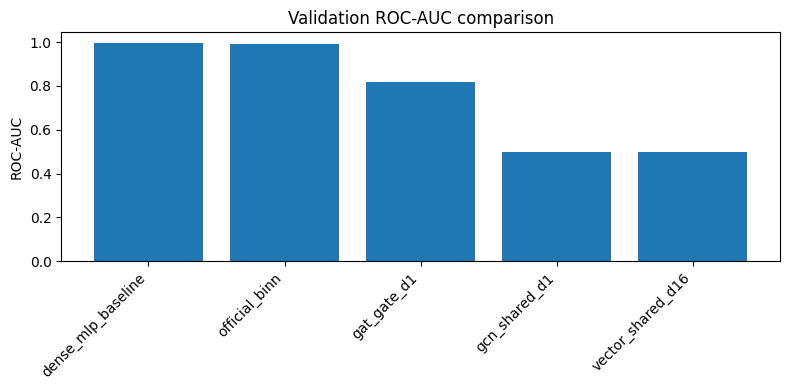

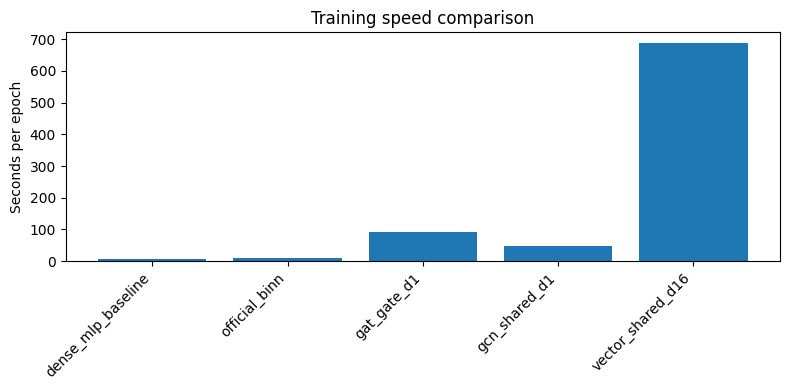

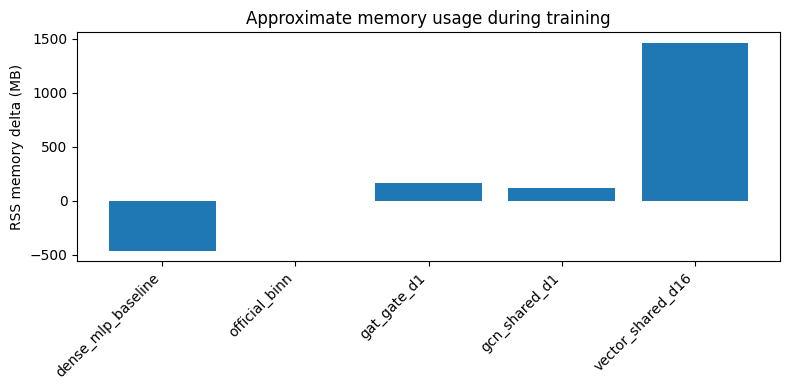

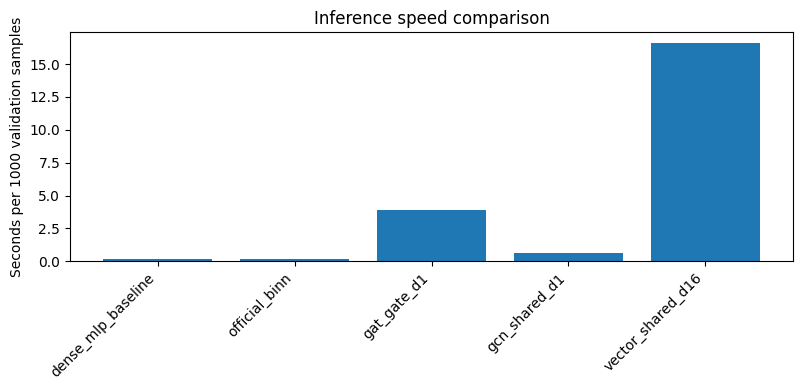

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure dataframe exists
assert "df_all" in globals(), "df_all not found. Run comparison block first."

# Sort by AUC for readability
df_plot = df_all.sort_values("auc", ascending=False)

models = df_plot["model"]

# -----------------------------
# ROC-AUC comparison
# -----------------------------
plt.figure(figsize=(8,4))
plt.bar(models, df_plot["auc"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("ROC-AUC")
plt.title("Validation ROC-AUC comparison")
plt.tight_layout()
plt.show()


# -----------------------------
# Training speed
# -----------------------------
plt.figure(figsize=(8,4))
plt.bar(models, df_plot["sec_per_epoch"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Seconds per epoch")
plt.title("Training speed comparison")
plt.tight_layout()
plt.show()


# -----------------------------
# Memory usage
# -----------------------------
plt.figure(figsize=(8,4))
plt.bar(models, df_plot["rss_mb_delta"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RSS memory delta (MB)")
plt.title("Approximate memory usage during training")
plt.tight_layout()
plt.show()


# -----------------------------
# Inference speed
# -----------------------------
plt.figure(figsize=(8,4))
plt.bar(models, df_plot["sec_per_1k_infer"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Seconds per 1000 validation samples")
plt.title("Inference speed comparison")
plt.tight_layout()
plt.show()
